# Phase 3: Model Architecture Comparison
**Objective:** We will benchmark a classical statistical model (ARIMA) against a deep learning approach (LSTM). We isolate a single store and department to evaluate how well each model predicts a 8-week forecast horizon.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")

# 1. FIX: Load the dataframe into this notebook's memory!
df = pd.read_csv('../data/train.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 2. Isolate the specific store
store1_dept1 = df[(df['Store'] == 1) & (df['Dept'] == 1)].sort_values('Date').set_index('Date')['Weekly_Sales']

# 3. Train/Test Split
forecast_steps = 8
train_series = store1_dept1.iloc[:-forecast_steps]
test_series = store1_dept1.iloc[-forecast_steps:]

print(f"Training records: {len(train_series)} weeks")
print(f"Testing records: {len(test_series)} weeks")

Training records: 135 weeks
Testing records: 8 weeks


## 1. The Baseline: ARIMA (AutoRegressive Integrated Moving Average)
We configure an ARIMA(5,1,0) model. This looks at the previous 5 weeks to predict the next week, using 1 degree of differencing to stabilize the trend.

In [2]:
# Utilizing your exact model.py logic
arima_model = ARIMA(train_series, order=(5,1,0))
arima_fit = arima_model.fit()

# Forecast 8 steps ahead
arima_preds = arima_fit.forecast(steps=8)

arima_mae = mean_absolute_error(test_series, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_preds))

print(f"ARIMA MAE: {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")

ARIMA MAE: 4952.15
ARIMA RMSE: 5750.78


## 2. The Challenger: LSTM Neural Network
We utilize a Sequential model with 50 LSTM units to capture non-linear demand shocks. The data is scaled using MinMaxScaler to ensure rapid gradient convergence.

In [3]:
# Utilizing your exact lstm_model.py logic
window_size = 4
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_series.values.reshape(-1, 1))

# Prepare sliding windows
X_train, y_train = [], []
for i in range(window_size, len(scaled_train)):
    X_train.append(scaled_train[i-window_size:i])
    y_train.append(scaled_train[i])
X_train, y_train = np.array(X_train), np.array(y_train)

# Build and train your exact LSTM architecture
lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train
lstm_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0)

# Forecast logic
input_seq = scaled_train[-window_size:]
lstm_preds_scaled = []
for _ in range(8):
    pred = lstm_model.predict(input_seq.reshape(1, window_size, 1), verbose=0)
    lstm_preds_scaled.append(pred[0][0])
    input_seq = np.append(input_seq[1:], pred, axis=0)

lstm_preds = scaler.inverse_transform(np.array(lstm_preds_scaled).reshape(-1,1)).flatten()

lstm_mae = mean_absolute_error(test_series, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(test_series, lstm_preds))

print(f"LSTM MAE: {lstm_mae:.2f}")
print(f"LSTM RMSE: {lstm_rmse:.2f}")

LSTM MAE: 2460.31
LSTM RMSE: 2867.55


## 3. Visual Comparison

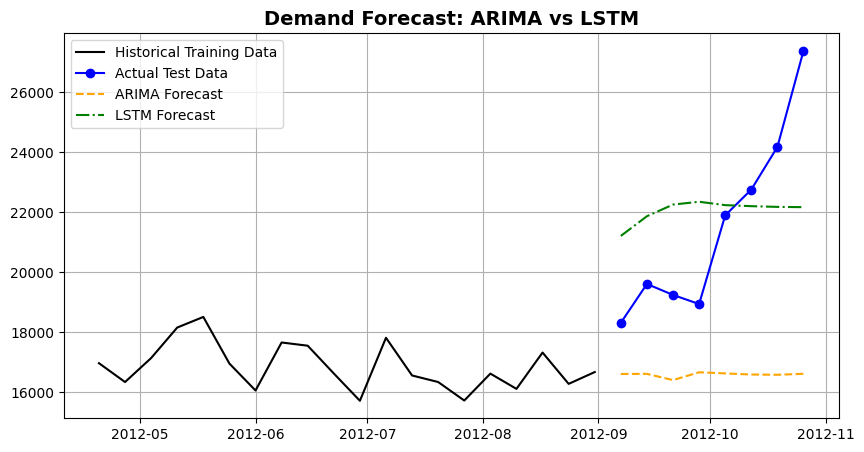

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(train_series.index[-20:], train_series.values[-20:], label='Historical Training Data', color='black')
plt.plot(test_series.index, test_series.values, label='Actual Test Data', marker='o', color='blue')
plt.plot(test_series.index, arima_preds, label='ARIMA Forecast', linestyle='--', color='orange')
plt.plot(test_series.index, lstm_preds, label='LSTM Forecast', linestyle='-.', color='green')

plt.title('Demand Forecast: ARIMA vs LSTM', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()